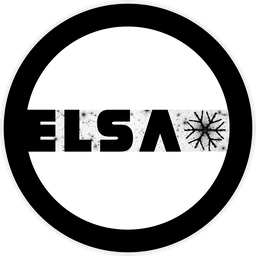

# GELSA tutorial: Emission line maps
**[ELSA](https://elsa-euclid.github.io/): Euclid Legacy Science Advanced analysis tools**

**Author(s):** Ben Granett, Louis Gabarra

**Last modified:** 2026-09-28

**Notebook summary:**

This notebook demonstrates how to build an emission line map from Euclid NISP exposures. The data are accessed from the data volumes mounted on ESA Datalabs. [Azulero](https://kabasset.github.io/azulero/) is used to make colour images from the Euclid VIS, Y, J, H images.

**Useful links:**

* [GELSA notebooks](https://github.com/elsa-euclid/gelsa/gelsa-notebooks/)
* [Documentation](https://elsa-euclid.github.io/gelsa/)
* [Code repository](https://github.com/elsa-euclid/gelsa/)

**Feedback:**

Use the [GELSA issue tracker](https://github.com/elsa-euclid/gelsa/issues) to report bugs or suggest features. Contributions are welcome!

**Acknowledgements:**

If you use GELSA for publications, please include the acknowledgement for the ELSA project below.

"ELSA: Euclid Legacy Science Advanced analysis tools" (Grant Agreement no. 101135203) is funded by the European Union. Views and opinions expressed are however those of the author(s) only and do not necessarily reflect those of the European Union or Innovate UK. Neither the European Union nor the granting authority can be held responsible for them. UK participation is funded through the UK Horizon guarantee scheme under Innovate UK grant 10093177.

**License:**

Copyright 2024–2026 the GELSA contributors. This file is subject to the terms and conditions defined in LICENSE.txt, which forms part of this source code package. No part of the package, including this file, may be copied, modified, propagated, or distributed except according to the terms contained in LICENSE.txt.

<br clear="left">

In [1]:
import logging
from tqdm.auto import tqdm

from matplotlib import pyplot as plt
import numpy as np

from astroquery.esa.euclid.core import EuclidClass

import gelsa
from gelsa import analysis
import gelsa.continuum_subtraction as cs
from gelsa.esa import euclid_archive

logging.basicConfig(level=logging.WARNING)

print(f"Gelsa version {gelsa.version.version}")

Gelsa version 4.0


## 1. Initialize Euclid archive connection and GELSA

In [2]:
Euclid = EuclidClass(environment='IDR')
Euclid.login(credentials_file='/media/home/my_workspace/password')

INFO:astroquery:Login to Euclid TAP server: easidr.esac.esa.int:443/tap-server/tap/
INFO:astroquery:OK
INFO:astroquery:Login to Euclid data service: easidr.esac.esa.int:443/sas-dd/tap-server/
INFO:astroquery:OK
INFO:astroquery:Login to Euclid cutout service: easidr.esac.esa.int:443/sas-cutout/tap-server/


INFO: Login to Euclid TAP server: easidr.esac.esa.int:443/tap-server/tap/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to Euclid data service: easidr.esac.esa.int:443/sas-dd/tap-server/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to Euclid cutout service: easidr.esac.esa.int:443/sas-cutout/tap-server/ [astroquery.esa.euclid.core]


INFO:astroquery:OK


INFO: OK [astroquery.utils.tap.core]


In [3]:
EA = euclid_archive.EuclidArchive(Euclid, survey_schema='catalogue'
)

In [4]:
# initialize gelsa and analysis class
G = gelsa.Gelsa()

A = analysis.Analysis(G)

## 2. Set a target

The example targets are from Gabarra+2026, in prep. They are all in the COSMOS field and covered by red and blue grism exposures.

In [5]:
targets = {
    'dinosaur': (150.093820, 2.503955, 0.751),
    'dual_agn': (150.278656, 1.970957, 0.528),
    'spiral1': (149.902457, 2.113313, 0.536),
    'spiral2': (150.247171,2.379908,0.6959),
    'spiral3': (149.983264, 2.479722, 0.7043),
    'dinosaur': (150.093820, 2.503955, 0.751),
    'tidal_chain': (150.048274, 2.591703, 0.80064)
}

ra, dec, redshift = targets['dinosaur']

## 3. Make a colour image
The first cell loads the VIS, Y, J and H stamps from the MER mosaics. The
second turns them into a colour image with Azulero's IYJH transform and shows
it beside the transform's parameters, so the image updates as they are edited.

* **Range**: *stretch*, *black point* and *white point* set the asinh dynamic
  range in AB magnitudes and do most of the work.
* **Colour** and **Band gain** decide how much of each band reaches each output
  channel.
* *Reset colour* returns to the defaults the line map studio also starts from;
  *Azulero defaults* returns to the library's own, which are tuned for wide
  mosaics and look fainter on a small stamp.

`colour.transform()` is the resulting `azulero.image.color.Transform`, and
`colour.rgb()` the RGB image.

In [6]:
stamps = []
for filter in ['VIS', 'NIR_Y', 'NIR_J', 'NIR_H']:
    stamp, wcs = EA.load_stamp(ra, dec,
                               width=101,
                               height=101,
                               filter=filter,
                               survey='cosmos')
    stamps.append(stamp)

In [7]:
from gelsa.esa import azulero_gui

azulero_widget = azulero_gui.make_azulero_gui(stamps, wcs)
azulero_widget

## 4. Retrieve the SIR frame file list

This cell submits a query to the Euclid archive for SIR frames that are near to the specified RA, Dec poistion.
The blue grism frames are kept.

In [8]:
sir_frame_list = EA.query_sir_frames(ra, dec, radius_deg=0.5)

# filter the frames for blue grism
sir_frame_list = [v for v in sir_frame_list if 'BGS' in v]

print(f"Found this many SIR frames: {len(sir_frame_list)}")

Found this many SIR frames: 240


In [9]:
# load SIR frame fits files
A.read_file_list(sir_frame_list)

# 5. Define the continuum subtraction routine

The emission line is isolated from the continuum by running continuum subtraction on the 2D image.
The `MedianFilterCutout` routine runs a median filter on the crop to estimate the continuum.
The procedure can be customized with the GELSA `continuum_subtraction_base` class.

In [10]:
continuum_subtraction = cs.MedianFilterCutout(50, redhift=redshift, mask_lines=True)

## 6. Crop the SIR frames on the target

Now crop the target on each SIR frame and subtract the continuum.

In [11]:
A.crop(
    ra, dec, 
    continuum_subtraction=continuum_subtraction,
    progress_hook=tqdm(total=len(A)).update
)

print(f"number of crops: {len(A.crop_list)}")

  0%|          | 0/240 [00:00<?, ?it/s]

number of crops: 184


### Plot the detector footprints on the sky. 

The target is marked by the star. We are plotting the detectors that contribute to the crops. The pixel to sky coordinate mapping is computed at 12200A. This wavelength at the blue side of the red grism corresponds roughly to the position of the galaxy in the direct image.

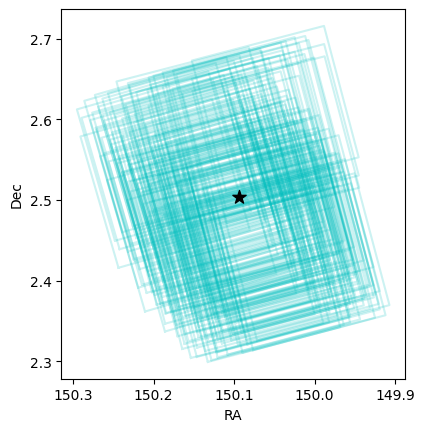

In [12]:
ax = plt.subplot(111, aspect=1./np.cos(np.radians(dec)))
xx = np.array([0, 2040, 2040, 0, 0])
yy = np.array([0, 0, 2040, 2040, 0])
for crop in A.crop_list:        # loop over crops
    for det in crop.keys():
        frame = crop[det].frame
        ra_, dec_ = frame.pixel_to_radec(xx, yy, det, wavelength=12200)
        ax.plot(ra_, dec_, alpha=0.2, c='c')
ax.scatter(ra, dec, marker="*", s=100, c='k', zorder=100)
ax.invert_xaxis()
ax.set_xlabel("RA")
_ = ax.set_ylabel("Dec")

## 7. Build the co-added spectrum

This cell extracts the spectrum from each crop after continuum subtraction. It resamples on a uniform wavelength scale, and co-adds the spectra.
It produces the 2D and 1D spectrum products.

**Parameters:**
* `wave_range` - sets the wavelength range in angstroms to extract.
* `extraction_profile` - the extraction profile for the 1D spectrum, `gaussian` or `flat`.
* `extraction_sigma_arsec` - specifies the width of the Gaussian kernel in arcsec.
* `extraction_window_pix` - the width of the extraction window in NISP pixels.



In [13]:
spec_pack = A.build_stacked_2D_spectrum(
    wave_range=(9300, 13000),
    extraction_profile='gaussian',
    extraction_sigma_arcsec=0.5,
    extraction_window_pix=21,
    progress_hook=tqdm(total=len(A)).update
)

  0%|          | 0/184 [00:00<?, ?it/s]

Text(0, 0.5, 'Flux')

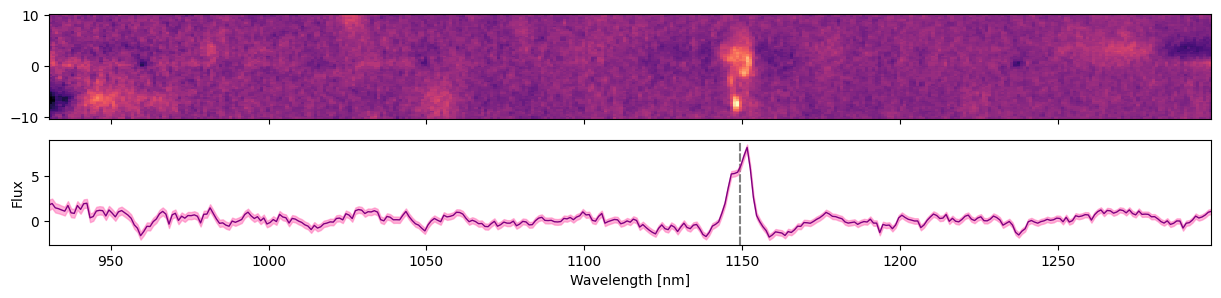

In [14]:
plt.figure(figsize=(15,3))
ax = plt.subplot(211)
wavelength = spec_pack['wavelength']/10
perp = spec_pack['pixel_perp']
ax.imshow(spec_pack['spec2d'], 
          extent=(wavelength[0], wavelength[-1], perp[0], perp[-1]), 
          cmap='magma',
          interpolation='nearest',
          aspect='auto')
ax.set_xticklabels([])
ax.set_xlim(wavelength[0], wavelength[-1])

ax2 = plt.subplot(212)
y = spec_pack['spec1d'] * 1e18
sigma = spec_pack['spec1d_var']**.5 * 1e18
ax2.fill_between(wavelength, y-sigma, y+sigma, 
                 alpha=0.5, color='hotpink')
ax2.plot(wavelength, y, lw=1, c='purple')

ax2.axvline(656.4*(1+redshift), dashes=[4,1], c='grey', zorder=0)
ax2.set_xlim(wavelength[0], wavelength[-1])
ax2.set_xlabel('Wavelength [nm]')
ax2.set_ylabel('Flux')

In [15]:
line_maps = {}
for wavelength in [6564.6]:
    print(f"building map at {wavelength}")
    elmap, elmap_var, elmap_norm, elmap_count = A.build_stacked_line_map(
        wavelength*(1+redshift),
        wcs,
        ndrops=100,
        progress_hook=tqdm(total=len(A)).update
    )
    line_maps[wavelength] = (elmap, elmap_var, elmap_norm, elmap_count)
    

building map at 6564.6


  0%|          | 0/184 [00:00<?, ?it/s]

In [16]:
def overplot_dispersion_direction(A, wcs, wavelength, x_center=None, y_center=None, length_angstrom=50, **plot_params):
    """ """
    length_pix = length_angstrom / 13.4 * 3  # convert angstrom to VIS pixels
    if x_center is None:
        x_center =length_pix+5
        y_center = length_pix+5
    ra0, dec0 = wcs.all_pix2world(wcs.array_shape[1]//2, wcs.array_shape[0]//2, 0)
    for crops in A.crop_list:
        for det, crop in crops.items():
            x_, y_ = crop.radec_to_pixel_(ra0, dec0, wavelength)
            if (x_ < 0) or (y_ < 0):
                continue
            if (x_ > crop.shape[1]) or (y_ > crop.shape[0]):
                continue
            theta = crop.get_dispersion_direction_on_wcs(wcs)
            dx = length_pix*np.sin(theta)
            dy = length_pix*np.cos(theta)
            plt.plot([x_center, x_center+dx], [y_center, y_center+dy], **plot_params)


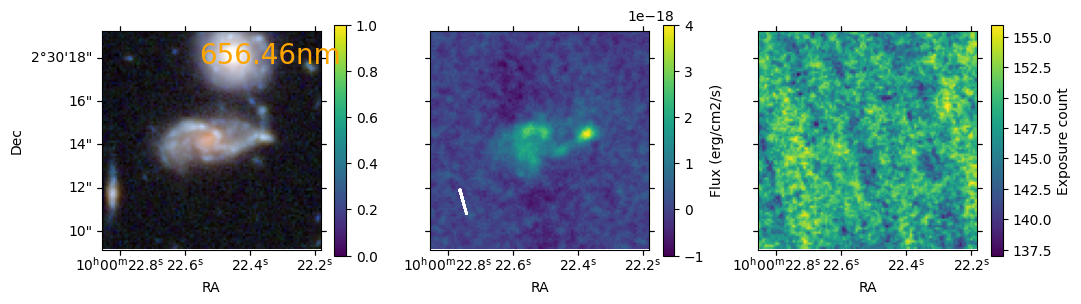

In [17]:

for wavelength in line_maps.keys():
    elmap, elmap_var, elmap_norm, elmap_count = line_maps[wavelength]
    
    plt.figure(figsize=(12,3))
    ax1=plt.subplot(131, projection=wcs)
    im = ax1.imshow(azulero_widget.rgb())
    plt.colorbar(im, ax=ax1)
    ax1.set_xlabel("RA")
    ax1.set_ylabel("Dec")

    ax2=plt.subplot(132, projection=wcs)
    ax2.text(.01, .99, f"{wavelength/10}nm", va='top', transform=ax.transAxes, c='orange', fontsize=20)
    im = ax2.imshow(elmap, vmin=-1e-18, vmax=4e-18)
    plt.colorbar(im, ax=ax2, label='Flux (erg/cm2/s)')

    overplot_dispersion_direction(A, wcs, wavelength*(1+redshift), c='w', alpha=0.8)

    ax2.set_ylabel("")
    ax2.set_xlabel("RA")
    ax2.coords[1].set_ticklabel(visible=False)

    ax3=plt.subplot(133, projection=wcs)
    im = ax3.imshow(elmap_count)
    plt.colorbar(im, ax=ax3, label='Exposure count')
    ax3.set_xlabel("RA")
    ax3.set_ylabel("")
    ax3.coords[1].set_ticklabel(visible=False)


## Build the figure interactively

The line map studio takes over the stamps, the crops and the Halpha map built
above, so the figure can be tuned while watching it instead of by re-running
cells.

* **Archive & calibration** holds the archive login and the gelsa calibration
  files. The studio reuses the `Euclid` and `G` handed to it, so there is
  nothing to do here unless you want to change them.
* **Target & data** holds the target and the stacking parameters. *Restack line
  map* reruns `A.build_stacked_line_map` on the crops already made, e.g. after
  changing the rest line; *Load target* fetches a new target from the archive.
  Wavelengths are in nm throughout the GUI.
* **Continuum colour** drives `azulero.image.color.Transform`: stretch, black
  point and white point set the asinh dynamic range in AB magnitudes and do most
  of the work; the blend and gain boxes decide how much of each band reaches
  each output channel.
* **Line colouring** either tints the line map with a single hue, or paints it
  with `gelsa.colorize` so the hue says which wavelength the light came from.
  The rainbow needs a trace of one exposure's dispersion: press *Build hue map*.
* **Layout** picks the panels and everything drawn on top of the pixels: sky
  axes, scale bar and N/E compass.
* **Export** writes the figure exactly as previewed, at publication DPI, writes
  the line map to FITS, and can save or reload the settings as JSON.

Everything the studio builds stays on the object: `studio.line_map`,
`studio.hue_rgb`, `studio.figure()` and `studio.transform()`.

In [18]:
from gelsa.esa import line_map_studio

studio = line_map_studio.make_line_map_studio(Euclid=Euclid, G=G, outdir='.')
studio.seed(
    stamps, wcs, A, ra, dec,
    redshift=redshift,
    rest_line='Ha 656.5',
    line_map=line_maps[6564.6],   # reuse the map stacked above
)
studio